In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('data/results.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)


In [38]:
#Calcular resultado de cada partido
def calculate_result(row):
    if row['home_score'] > row['away_score']:
        return 1
    elif row['home_score'] < row['away_score']:
        return 2
    else:
        return 0
    
df['result'] = df.apply(calculate_result, axis=1)
df

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,0
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1
...,...,...,...,...,...,...,...,...,...,...
49282,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True,0
49283,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True,0
49284,2026-06-27,Algeria,Austria,NaN,NaN,FIFA World Cup,Kansas City,United States,True,0
49285,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True,0


In [39]:
# Asignamos un peso del 1 al 4 según la relevancia competitiva
def tournament_weight(tournament):
    torneo = str(tournament)
    if 'FIFA World Cup' in torneo and 'FIFA World Cup qualification' not in torneo:
        return 4  # El Mundial 
    elif 'Copa América' in torneo or 'UEFA Euro' in torneo and 'qualification' not in torneo:
        return 3  # Torneos continentales
    elif 'FIFA World Cup qualification' in torneo or 'nations league' in torneo or 'confederations' in torneo:
        return 2  # Clasificatorios y torneos oficiales menores
    elif 'Friendly' in torneo:
        return 1  # Amistosos
    else:
        return 1.5 # Otros torneos menores (Copas de invitación, etc.)

df['tournament_weight'] = df['tournament'].apply(tournament_weight)
df

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,tournament_weight
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,0,1.0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1,1.0
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1,1.0
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,0,1.0
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...
49282,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True,0,4.0
49283,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True,0,4.0
49284,2026-06-27,Algeria,Austria,NaN,NaN,FIFA World Cup,Kansas City,United States,True,0,4.0
49285,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True,0,4.0


In [40]:
# Extraemos los datos del equipo LOCAL
df_local = df[['date', 'home_team', 'home_score', 'away_score', 'result']].rename(
    columns={'home_team': 'team', 'home_score': 'goals_for', 'away_score': 'goals_against'}
)
df_local['points'] = df_local['result'].map({1: 3, 0: 1, 2: 0})

# Extraemos los datos del equipo VISITANTE
df_away = df[['date', 'away_team', 'away_score', 'home_score', 'result']].rename(
    columns={'away_team': 'team', 'away_score': 'goals_for', 'home_score': 'goals_against'}
)
df_away['points'] = df_away['result'].map({1: 0, 0: 1, 2: 3})

df_time = pd.concat([df_local, df_away]).sort_values('date')

df_time

,date,team,goals_for,goals_against,result,points
0,1872-11-30,Scotland,0.0,0.0,0,1
0,1872-11-30,England,0.0,0.0,0,1
1,1873-03-08,Scotland,2.0,4.0,1,0
1,1873-03-08,England,4.0,2.0,1,3
2,1874-03-07,England,1.0,2.0,1,0
...,...,...,...,...,...,...
49283,2026-06-27,Panama,NaN,NaN,0,1
49282,2026-06-27,Colombia,NaN,NaN,0,1
49281,2026-06-27,DR Congo,NaN,NaN,0,1
49285,2026-06-27,Argentina,NaN,NaN,0,1


In [41]:
# calculamos medias moviles de goles y puntos para cada equipo
def calculate_moving_averages(df, window=30):
    df = df.sort_values('date')
    group = df.groupby('team')
    df['avg_goals_for'] = group['goals_for'].shift(1).rolling(window=window, min_periods=1).mean()
    df['avg_goals_against'] = group['goals_against'].shift(1).rolling(window=window, min_periods=1).mean()
    df['avg_points'] = group['points'].shift(1).rolling(window=window, min_periods=1).mean()
    return df
df_time = calculate_moving_averages(df_time)
df_clean = df_time[['date', 'team', 'avg_goals_for', 'avg_goals_against', 'avg_points']].drop_duplicates(subset=['date', 'team'])

df_clean


,date,team,avg_goals_for,avg_goals_against,avg_points
0,1872-11-30,Scotland,NaN,NaN,NaN
0,1872-11-30,England,NaN,NaN,NaN
1,1873-03-08,Scotland,0.000000,0.000000,1.000000
1,1873-03-08,England,0.000000,0.000000,1.000000
2,1874-03-07,England,1.333333,0.666667,1.666667
...,...,...,...,...,...
49282,2026-06-27,Portugal,NaN,NaN,1.000000
49281,2026-06-27,Uzbekistan,NaN,NaN,1.000000
49285,2026-06-27,Argentina,NaN,NaN,1.000000
49286,2026-06-27,Croatia,NaN,NaN,1.000000


In [42]:
#volvemos a la estructura original con un row por partido

df = df.merge(df_clean, left_on=['date', 'home_team'], right_on=['date', 'team'], how='left')
df = df.rename(columns={
    'avg_goals_for': 'avg_goals_for_local', 
    'avg_goals_against': 'avg_goals_against_local',
    'avg_points': 'avg_points_local'
}).drop(columns=['team'])

df = df.merge(df_clean, left_on=['date', 'away_team'], right_on=['date', 'team'], how='left')
df = df.rename(columns={
    'avg_goals_for': 'avg_goals_for_away', 
    'avg_goals_against': 'avg_goals_against_away',
    'avg_points': 'avg_points_away'
}).drop(columns=['team'])


df


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,tournament_weight,avg_goals_for_local,avg_goals_against_local,avg_points_local,avg_goals_for_away,avg_goals_against_away,avg_points_away
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1,1.0,0.000,0.000,1.000000,0.000000,0.000000,1.000000
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1,1.0,1.500,1.500,1.250000,1.333333,0.666667,1.666667
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,0,1.0,1.500,1.500,1.333333,1.600000,1.400000,1.600000
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1,1.0,1.625,1.625,1.250000,1.571429,1.571429,1.285714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49282,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True,0,4.0,NaN,NaN,1.000000,NaN,NaN,1.000000
49283,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True,0,4.0,NaN,NaN,1.000000,NaN,NaN,1.000000
49284,2026-06-27,Algeria,Austria,NaN,NaN,FIFA World Cup,Kansas City,United States,True,0,4.0,NaN,NaN,1.000000,NaN,NaN,1.000000
49285,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True,0,4.0,NaN,NaN,1.000000,NaN,NaN,1.000000


In [43]:
# calculamos diferencias entre local y visitante
df['diff_avg_goals_for'] = df['avg_goals_for_local'] - df['avg_goals_for_away']
df['diff_avg_goals_against'] = df['avg_goals_against_local'] - df['avg_goals_against_away']
df['diff_avg_points'] = df['avg_points_local'] - df['avg_points_away']


In [44]:
# unificamos los archivos de ranking en uno solo para facilitar el merge_asof posterior
ranking_files = [
    'data/fifa_ranking-2023-07-20.csv',  # Cambia estos nombres por tus rutas reales
    'data/fifa_ranking-2024-04-04.csv',
    'data/fifa_ranking-2024-06-20.csv'
]

# Leemos y concatenamos los tres archivos en uno solo
df_ranking = pd.concat([pd.read_csv(f) for f in ranking_files], ignore_index=True)
# Convertimos la fecha a formato datetime
df_ranking['rank_date'] = pd.to_datetime(df_ranking['rank_date'])

# Nos quedamos solo con las columnas que aportan valor al modelo
df_ranking_clean = df_ranking[['rank_date', 'country_full', 'total_points', 'rank']].copy()

df_ranking_clean


,rank_date,country_full,total_points,rank
0,1992-12-31,Germany,57.00,1.0
1,1992-12-31,Syria,11.00,96.0
2,1992-12-31,Burkina Faso,11.00,97.0
3,1992-12-31,Latvia,10.00,99.0
4,1992-12-31,Burundi,10.00,100.0
...,...,...,...,...
199485,2024-06-20,Kuwait,1098.42,137.0
199486,2024-06-20,Lithuania,1100.66,136.0
199487,2024-06-20,Malaysia,1107.58,135.0
199488,2024-06-20,Solomon Islands,1111.02,133.0


In [45]:
# Filtramos los partidos para empezar a partir del 1 de enero de 1993
df_final = df[df['date'] >= '1993-01-01'].copy()
df_final = df_final.sort_values('date')
df_final

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,tournament_weight,avg_goals_for_local,avg_goals_against_local,avg_points_local,avg_goals_for_away,avg_goals_against_away,avg_points_away,diff_avg_goals_for,diff_avg_goals_against,diff_avg_points
18704,1993-01-01,Ghana,Mali,1.0,1.0,Friendly,Libreville,Gabon,True,0,1.0,1.266667,1.566667,1.200000,1.233333,1.600000,1.166667,0.033333,-0.033333,0.033333
18705,1993-01-02,Gabon,Burkina Faso,1.0,1.0,Friendly,Libreville,Gabon,False,0,1.0,1.400000,1.533333,1.366667,1.333333,1.533333,1.266667,0.066667,0.000000,0.100000
18706,1993-01-02,Kuwait,Lebanon,2.0,0.0,Friendly,Kuwait City,Kuwait,False,1,1.0,1.300000,1.533333,1.266667,1.233333,1.533333,1.233333,0.066667,0.000000,0.033333
18707,1993-01-03,Burkina Faso,Mali,1.0,0.0,Friendly,Libreville,Gabon,True,1,1.0,1.200000,1.500000,1.200000,1.266667,1.433333,1.266667,-0.066667,0.066667,-0.066667
18708,1993-01-03,Gabon,Ghana,2.0,3.0,Friendly,Libreville,Gabon,False,2,1.0,1.233333,1.500000,1.233333,1.300000,1.466667,1.266667,-0.066667,0.033333,-0.033333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49283,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True,0,4.0,NaN,NaN,1.000000,NaN,NaN,1.000000,NaN,NaN,0.000000
49285,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True,0,4.0,NaN,NaN,1.000000,NaN,NaN,1.000000,NaN,NaN,0.000000
49281,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True,0,4.0,NaN,NaN,1.000000,NaN,NaN,1.000000,NaN,NaN,0.000000
49282,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True,0,4.0,NaN,NaN,1.000000,NaN,NaN,1.000000,NaN,NaN,0.000000


In [ ]:

df_ranking_clean_sorted = df_ranking_clean.sort_values('rank_date')

alternative_names = {
    'United States': 'USA',
    'South Korea': 'Korea Republic',
    'Korea': 'Korea Republic',
    'DR Congo': 'Congo',
    'South Africa': 'South Africa',
    'Burkina Faso': 'Burkina Faso'
}
df_final['home_team'] = df_final['home_team'].replace(alternative_names)
df_final['away_team'] = df_final['away_team'].replace(alternative_names)


df_unified = pd.merge_asof(
    df_final, 
    df_ranking_clean_sorted[['rank_date', 'country_full', 'total_points', 'rank']], 
    left_on='date', 
    right_on='rank_date', 
    left_by='home_team', 
    right_by='country_full', 
    direction='nearest'
)

df_unified = df_unified.rename(columns={'total_points': 'fifa_points_local', 'rank': 'ranking_local'})
df_unified = df_unified.drop(columns=['rank_date', 'country_full'], errors='ignore')

# Cruce para el Equipo Visitante
df_unified = pd.merge_asof(
    df_unified, 
    df_ranking_clean_sorted[['rank_date', 'country_full', 'total_points', 'rank']], 
    left_on='date', 
    right_on='rank_date', 
    left_by='away_team', 
    right_by='country_full', 
    direction='nearest'
)
df_unified = df_unified.rename(columns={'total_points': 'fifa_points_away', 'rank': 'ranking_away'})
df_unified = df_unified.drop(columns=['rank_date', 'country_full'], errors='ignore')

df_unified


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,...,avg_goals_for_away,avg_goals_against_away,avg_points_away,diff_avg_goals_for,diff_avg_goals_against,diff_avg_points,fifa_points_local,ranking_local,fifa_points_away,ranking_away
0,1993-01-01,Ghana,Mali,1.0,1.0,Friendly,Libreville,Gabon,True,0,...,1.233333,1.600000,1.166667,0.033333,-0.033333,0.033333,34.00,39.0,22.00,69.0
1,1993-01-02,Gabon,Burkina Faso,1.0,1.0,Friendly,Libreville,Gabon,False,0,...,1.333333,1.533333,1.266667,0.066667,0.000000,0.100000,27.00,55.0,11.00,97.0
2,1993-01-02,Kuwait,Lebanon,2.0,0.0,Friendly,Kuwait City,Kuwait,False,1,...,1.233333,1.533333,1.233333,0.066667,0.000000,0.033333,21.00,71.0,0.00,161.0
3,1993-01-03,Burkina Faso,Mali,1.0,0.0,Friendly,Libreville,Gabon,True,1,...,1.266667,1.433333,1.266667,-0.066667,0.066667,-0.066667,11.00,97.0,22.00,69.0
4,1993-01-03,Gabon,Ghana,2.0,3.0,Friendly,Libreville,Gabon,False,2,...,1.300000,1.466667,1.266667,-0.066667,0.033333,-0.033333,27.00,55.0,34.00,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30578,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True,0,...,NaN,NaN,1.000000,NaN,NaN,0.000000,1482.10,43.0,1787.88,5.0
30579,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True,0,...,NaN,NaN,1.000000,NaN,NaN,0.000000,1374.13,68.0,1860.14,1.0
30580,2026-06-27,Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True,0,...,NaN,NaN,1.000000,NaN,NaN,0.000000,1176.45,113.0,1397.41,62.0
30581,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True,0,...,NaN,NaN,1.000000,NaN,NaN,0.000000,1669.44,12.0,1747.04,6.0


In [47]:
df_elo = pd.read_csv('data/eloratings.csv', parse_dates=['date'])
df_elo = df_elo[df_elo['date'] >= '1993-01-01'].copy()
df_elo = df_elo.rename(columns={'date': 'elo_date'})
df_elo.drop(columns=['change'], inplace=True)
df_elo['elo_date'] = pd.to_datetime(df_elo['elo_date'],format='%m/%d/%Y')
df_elo

,elo_date,team,rating
44,1901-03-23,Wales,1476.0
45,1901-03-23,Ireland,1338.0
54,1913-02-04,China,1566.0
55,1913-02-04,Philippines,1234.0
56,1915-05-18,China,1552.0
...,...,...,...
6325,2025-09-09,Maldives,869.0
6326,2025-09-09,Seychelles,845.0
6327,2025-09-09,San Marino,841.0
6328,2025-09-09,Sri Lanka,750.0


In [48]:
df_elo = df_elo.sort_values('elo_date')

df_unified_final = pd.merge_asof(
    df_unified, 
    df_elo[['elo_date', 'team', 'rating']], 
    left_on='date', 
    right_on='elo_date', 
    left_by='home_team', 
    right_by='team', 
    direction='nearest'
)
df_unified_final = df_unified_final.rename(columns={'rating': 'elo_local'})
df_unified_final = df_unified_final.drop(columns=['elo_date', 'team'], errors='ignore')

df_unified_final = pd.merge_asof(
    df_unified_final, 
    df_elo[['elo_date', 'team', 'rating']], 
    left_on='date', 
    right_on='elo_date', 
    left_by='away_team', 
    right_by='team', 
    direction='nearest'
)
df_unified_final = df_unified_final.rename(columns={'rating': 'elo_away'})
df_unified_final = df_unified_final.drop(columns=['elo_date', 'team'], errors='ignore')


df_unified_final['diff_elo'] = df_unified_final['elo_local'] - df_unified_final['elo_away']
df_unified_final['diff_ranking'] = df_unified_final['ranking_local'] - df_unified_final['ranking_away']
df_unified_final['diff_fifa_points'] = df_unified_final['fifa_points_local'] - df_unified_final['fifa_points_away']

df_unified_final.to_csv('data/processed_data.csv', index=False)

df_unified_final


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,...,diff_avg_points,fifa_points_local,ranking_local,fifa_points_away,ranking_away,elo_local,elo_away,diff_elo,diff_ranking,diff_fifa_points
0,1993-01-01,Ghana,Mali,1.0,1.0,Friendly,Libreville,Gabon,True,0,...,0.033333,34.00,39.0,22.00,69.0,1622.0,1404.0,218.0,-30.0,12.00
1,1993-01-02,Gabon,Burkina Faso,1.0,1.0,Friendly,Libreville,Gabon,False,0,...,0.100000,27.00,55.0,11.00,97.0,1443.0,NaN,NaN,-42.0,16.00
2,1993-01-02,Kuwait,Lebanon,2.0,0.0,Friendly,Kuwait City,Kuwait,False,1,...,0.033333,21.00,71.0,0.00,161.0,1491.0,1252.0,239.0,-90.0,21.00
3,1993-01-03,Burkina Faso,Mali,1.0,0.0,Friendly,Libreville,Gabon,True,1,...,-0.066667,11.00,97.0,22.00,69.0,NaN,1404.0,NaN,28.0,-11.00
4,1993-01-03,Gabon,Ghana,2.0,3.0,Friendly,Libreville,Gabon,False,2,...,-0.033333,27.00,55.0,34.00,39.0,1443.0,1622.0,-179.0,16.0,-7.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30578,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True,0,...,0.000000,1482.10,43.0,1787.88,5.0,1729.0,2019.0,-290.0,38.0,-305.78
30579,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True,0,...,0.000000,1374.13,68.0,1860.14,1.0,1634.0,2109.0,-475.0,67.0,-486.01
30580,2026-06-27,Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True,0,...,0.000000,1176.45,113.0,1397.41,62.0,1261.0,1708.0,-447.0,51.0,-220.96
30581,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True,0,...,0.000000,1669.44,12.0,1747.04,6.0,1981.0,2041.0,-60.0,6.0,-77.60


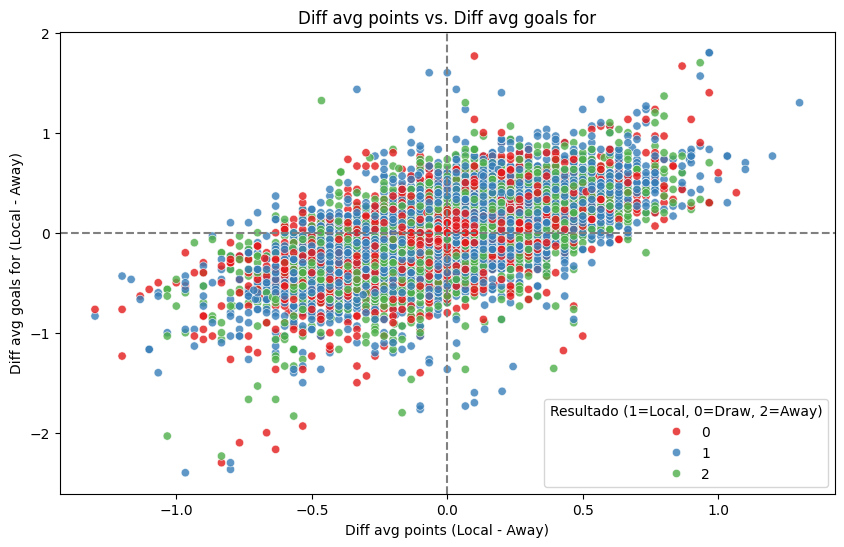

In [49]:
plt.figure(figsize=(10, 6))
# Gráfico de dispersión coloreado por el resultado del partido
sns.scatterplot(
    data=df_unified, 
    x='diff_avg_points', 
    y='diff_avg_goals_for', 
    hue='result', 
    palette='Set1', 
    alpha=0.8
)

plt.title('Diff avg points vs. Diff avg goals for')
plt.xlabel('Diff avg points (Local - Away)')
plt.ylabel('Diff avg goals for (Local - Away)')
plt.axhline(0, color='gray', linestyle='--') # Línea de equilibrio en Y
plt.axvline(0, color='gray', linestyle='--') # Línea de equilibrio en X
plt.legend(title='Resultado (1=Local, 0=Draw, 2=Away)')
plt.show()

C:\Users\TrendingPc\AppData\Local\Temp\ipykernel_2260\2486411133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_unified, x='result', y='ranking_local', palette='Set2')


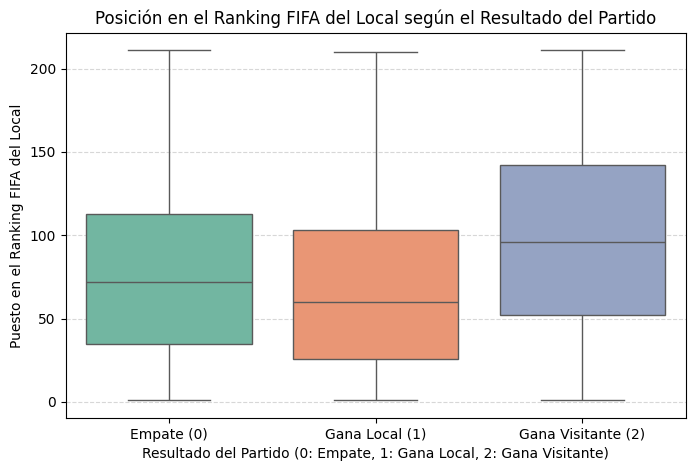

In [50]:
plt.figure(figsize=(8, 5))
# Creamos el boxplot
sns.boxplot(data=df_unified, x='result', y='ranking_local', palette='Set2')

plt.title('Posición en el Ranking FIFA del Local según el Resultado del Partido')
plt.xlabel('Resultado del Partido (0: Empate, 1: Gana Local, 2: Gana Visitante)')
plt.ylabel('Puesto en el Ranking FIFA del Local')
# Modificamos las etiquetas del eje X para que sea más legible
plt.xticks(ticks=[0, 1, 2], labels=['Empate (0)', 'Gana Local (1)', 'Gana Visitante (2)'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

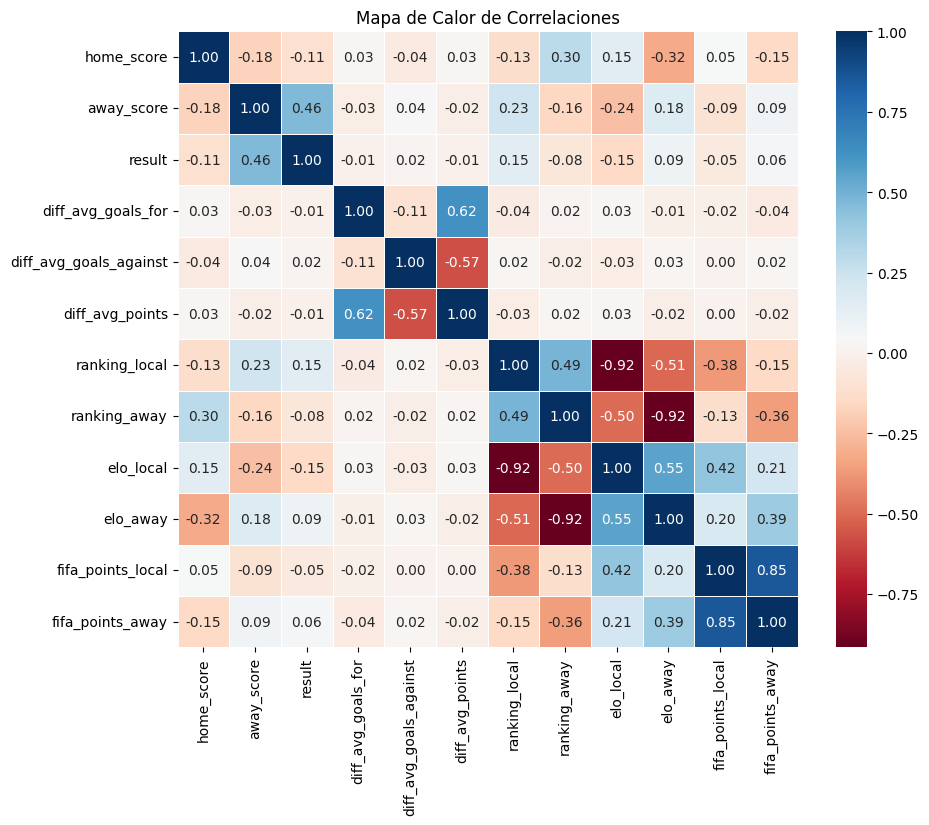

In [51]:

study_columns = [
    'home_score', 'away_score', 'result', 
    'diff_avg_goals_for', 'diff_avg_goals_against', 'diff_avg_points',
    'ranking_local', 'ranking_away', 'elo_local', 'elo_away', 'fifa_points_local', 'fifa_points_away',
]
correlation_matrix = df_unified_final[study_columns].corr()

plt.figure(figsize=(10, 8))
# Dibujamos el mapa de calor
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt=".2f", linewidths=0.5)

plt.title('Mapa de Calor de Correlaciones')
plt.show()

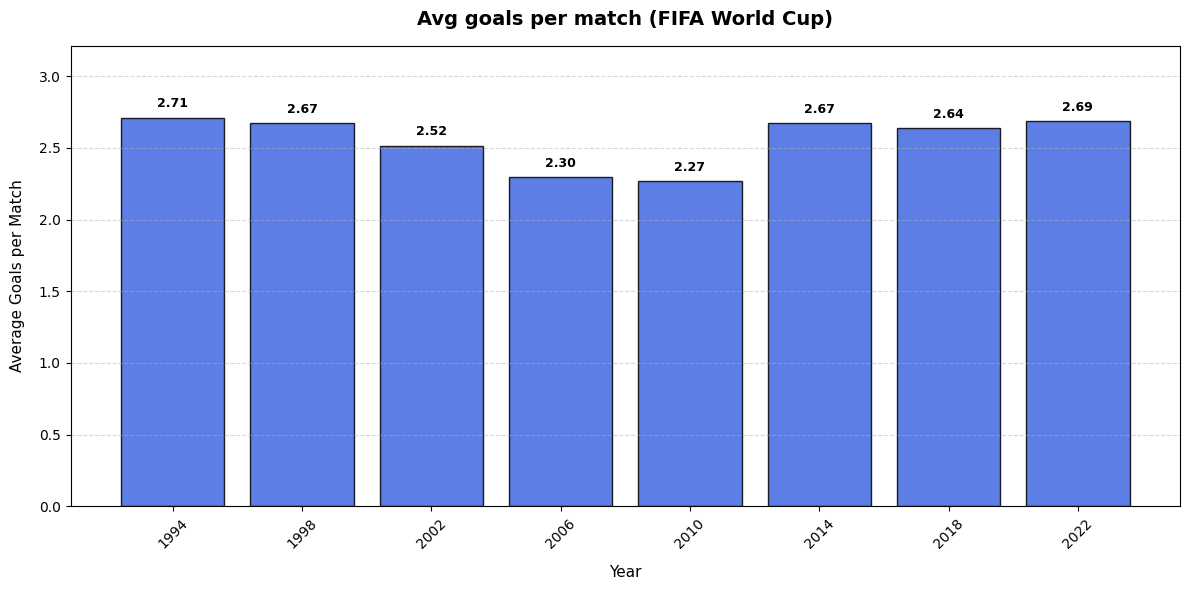

In [52]:

df_unified['date'] = pd.to_datetime(df_unified['date'])

# 2. Calcular los goles totales de cada partido
df_unified['total_goals'] = df_unified['home_score'] + df_unified['away_score']

# 3. Filtrar el DataFrame para quedarnos únicamente con los partidos de los Mundiales
df_world_cups = df_unified[df_unified['tournament'] == 'FIFA World Cup'].copy()

# 4. Extraer el año de la fecha para diferenciar cada edición del mundial
df_world_cups['year'] = df_world_cups['date'].dt.year

# 5. Agrupar por año y calcular la media de goles por partido en cada mundial
avg_goals = df_world_cups.groupby('year')['total_goals'].mean().reset_index()

# 6. Ordenar cronológicamente para que el gráfico fluya correctamente
media_goles_mundial = avg_goals.sort_values('year')

# --- DISEÑO DEL GRÁFICO DE BARRAS EN MATPLOTLIB ---
plt.figure(figsize=(12, 6))

# Dibujar las barras principales
barras = plt.bar(
    media_goles_mundial['year'].astype(str), # Convertimos a string para que actúen como etiquetas limpias en el eje X
    media_goles_mundial['total_goals'], 
    color='royalblue', 
    edgecolor='black',
    alpha=0.85
)

# Añadir los valores numéricos encima de cada barra para facilitar la lectura
for barra in barras:
    yval = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2.0, 
        yval + 0.05, 
        f'{yval:.2f}', # Formato con 2 decimales
        ha='center', 
        va='bottom', 
        fontsize=9, 
        fontweight='bold'
    )

# Configuración de títulos y etiquetas
plt.title('Avg goals per match (FIFA World Cup)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=11, labelpad=10)
plt.ylabel('Average Goals per Match', fontsize=11, labelpad=10)

# Mejoras visuales
plt.xticks(rotation=45) # Rotamos los años para evitar que se encimen si hay muchas ediciones
plt.ylim(0, avg_goals['total_goals'].max() + 0.5) # Damos margen superior para las etiquetas de texto
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Mostrar el resultado final
plt.tight_layout()
plt.show()

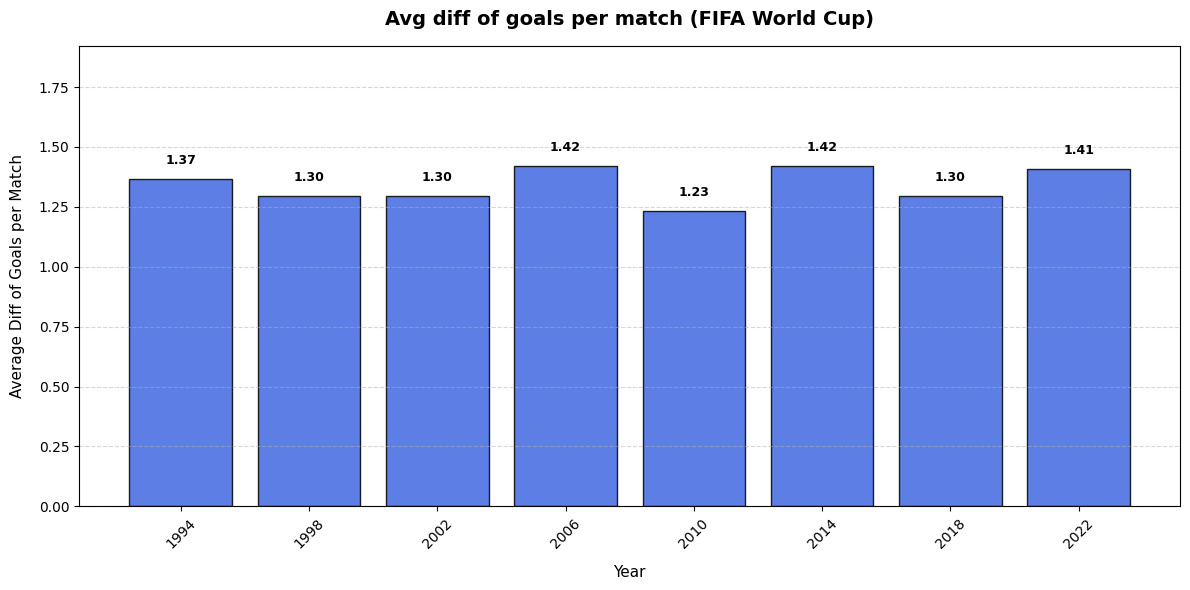

In [53]:

df_unified['diff_goals'] = (df_unified['home_score'] - df_unified['away_score']).abs()


df_world_cups = df_unified[df_unified['tournament'] == 'FIFA World Cup'].copy()

df_world_cups['year'] = df_world_cups['date'].dt.year

avg_goals = df_world_cups.groupby('year')['diff_goals'].mean().reset_index()

media_goles_mundial = avg_goals.sort_values('year')

# --- DISEÑO DEL GRÁFICO DE BARRAS EN MATPLOTLIB ---
plt.figure(figsize=(12, 6))

# Dibujar las barras principales
barras = plt.bar(
    media_goles_mundial['year'].astype(str), # Convertimos a string para que actúen como etiquetas limpias en el eje X
    media_goles_mundial['diff_goals'], 
    color='royalblue', 
    edgecolor='black',
    alpha=0.85
)

# Añadir los valores numéricos encima de cada barra para facilitar la lectura
for barra in barras:
    yval = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2.0, 
        yval + 0.05, 
        f'{yval:.2f}', # Formato con 2 decimales
        ha='center', 
        va='bottom', 
        fontsize=9, 
        fontweight='bold'
    )

# Configuración de títulos y etiquetas
plt.title('Avg diff of goals per match (FIFA World Cup)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=11, labelpad=10)
plt.ylabel('Average Diff of Goals per Match', fontsize=11, labelpad=10)

# Mejoras visuales
plt.xticks(rotation=45) # Rotamos los años para evitar que se encimen si hay muchas ediciones
plt.ylim(0, avg_goals['diff_goals'].max() + 0.5) # Damos margen superior para las etiquetas de texto
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Mostrar el resultado final
plt.tight_layout()
plt.show()

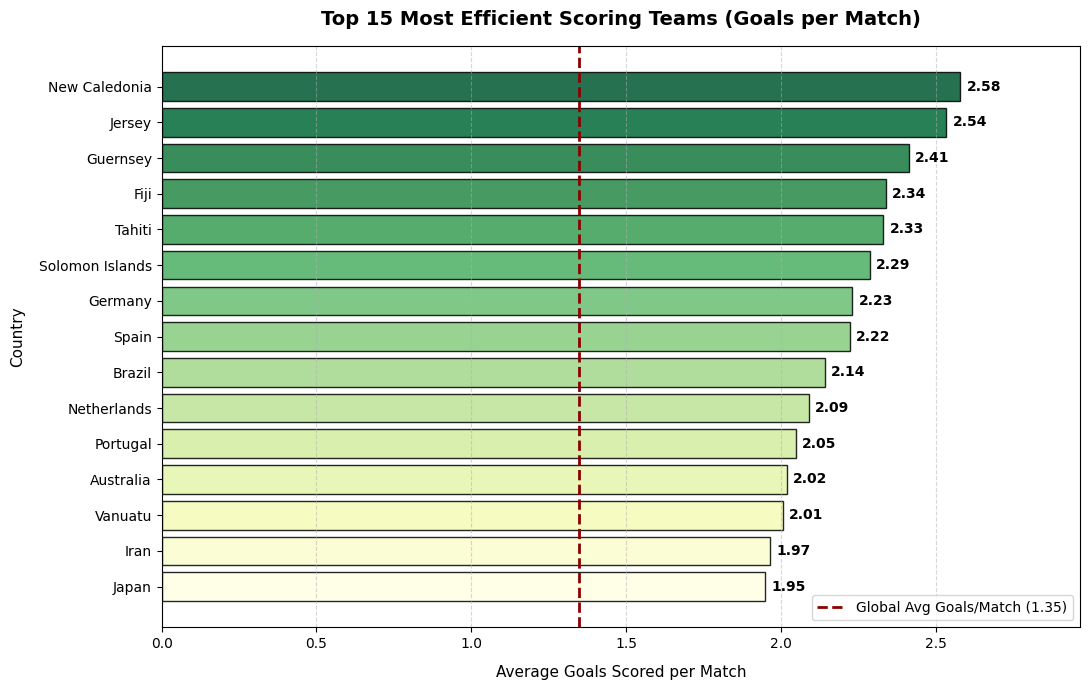

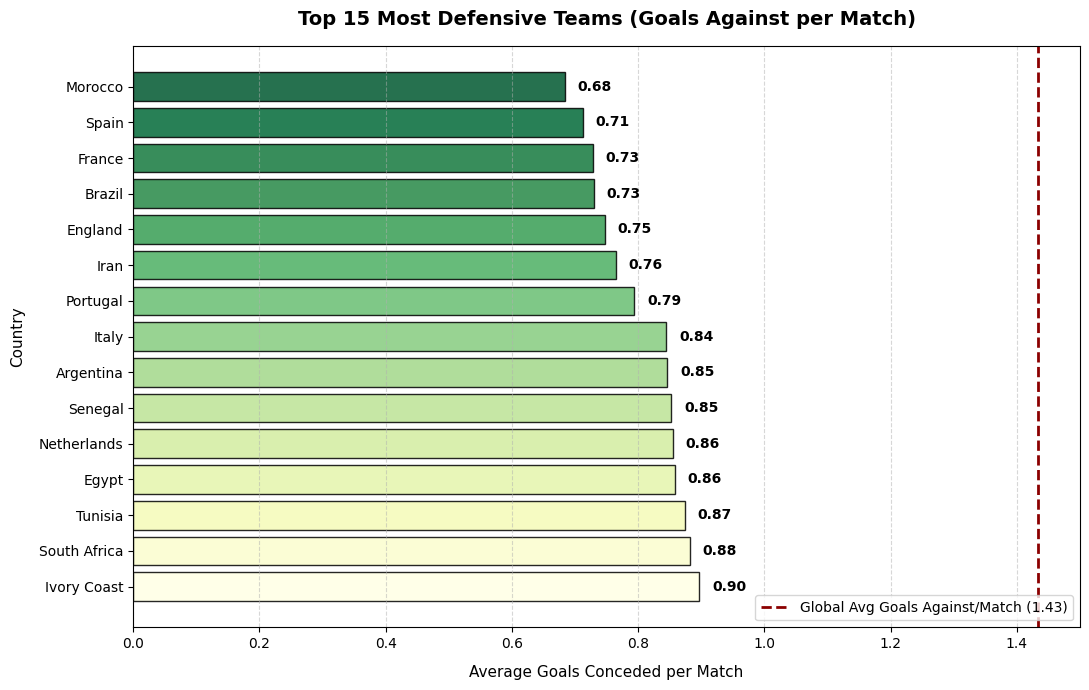

In [54]:
local_goals = df_unified.groupby('home_team').agg(
    goals_for=('home_score', 'sum'),
    goals_against=('away_score', 'sum')
).reset_index().rename(columns={'home_team': 'team'})


away_goals = df_unified.groupby('away_team').agg(
    goals_for=('away_score', 'sum'),
    goals_against=('home_score', 'sum')
).reset_index().rename(columns={'away_team': 'team'})

df_total_goals = pd.concat([local_goals, away_goals]).groupby('team').sum().reset_index()

local_matches = df_unified['home_team'].value_counts().reset_index().rename(columns={'home_team': 'team', 'count': 'local_matches'})
away_matches = df_unified['away_team'].value_counts().reset_index().rename(columns={'away_team': 'team', 'count': 'away_matches'})
df_partidos = pd.merge(local_matches, away_matches, on='team', how='outer').fillna(0)
df_partidos['total_matches'] = df_partidos['local_matches'] + df_partidos['away_matches']

df_partidos = df_partidos[df_partidos['total_matches'] > 100]

df_efficiency = pd.merge(df_total_goals, df_partidos[['team', 'total_matches']], on='team', how='inner')


df_efficiency['goals_per_match'] = df_efficiency['goals_for'] / df_efficiency['total_matches']

df_efficiency['goals_against_per_match'] = df_efficiency['goals_against'] / df_efficiency['total_matches']


avg_goals_per_match = df_efficiency['goals_per_match'].mean()
avg_goals_against_per_match = df_efficiency['goals_against_per_match'].mean()



top_eficientes = df_efficiency.sort_values(by='goals_per_match', ascending=True).tail(15)

top_defensivos = df_efficiency.sort_values(by='goals_against_per_match', ascending=False).tail(15)

plt.figure(figsize=(11, 7))
colors_efficiency = plt.cm.YlGn(pd.Series(range(len(top_eficientes))) / len(top_eficientes))

bars= plt.barh(
    top_eficientes['team'], 
    top_eficientes['goals_per_match'], 
    color=colors_efficiency, 
    edgecolor='black',
    alpha=0.85
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.02, 
        bar.get_y() + bar.get_height()/2.0, 
        f'{width:.2f}', 
        ha='left', va='center', fontsize=10, fontweight='bold'
    )


plt.axvline(avg_goals_per_match, color='darkred', linestyle='--', linewidth=2, label=f'Global Avg Goals/Match ({avg_goals_per_match:.2f})')
plt.legend(loc='lower right', fontsize=10)

plt.title('Top 15 Most Efficient Scoring Teams (Goals per Match)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Goals Scored per Match', fontsize=11, labelpad=10)
plt.ylabel('Country', fontsize=11, labelpad=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(0, top_eficientes['goals_per_match'].max() * 1.15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 7))
colors_defensive = plt.cm.YlGn(pd.Series(range(len(top_defensivos))) / len(top_defensivos))

bars= plt.barh(
    top_defensivos['team'], 
    top_defensivos['goals_against_per_match'], 
    color=colors_defensive, 
    edgecolor='black',
    alpha=0.85
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.02, 
        bar.get_y() + bar.get_height()/2.0, 
        f'{width:.2f}', 
        ha='left', va='center', fontsize=10, fontweight='bold'
    )


plt.axvline(avg_goals_against_per_match, color='darkred', linestyle='--', linewidth=2, label=f'Global Avg Goals Against/Match ({avg_goals_against_per_match:.2f})')
plt.legend(loc='lower right', fontsize=10)

plt.title('Top 15 Most Defensive Teams (Goals Against per Match)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Goals Conceded per Match', fontsize=11, labelpad=10)
plt.ylabel('Country', fontsize=11, labelpad=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(0,1.5)
plt.tight_layout()
plt.show()

